 Loaded: C:\datasources\testresults.csv (5 rows)

=== Questions & Comments (readable head) ===


,Test_number,Model,Question_text,Response_text,General_comment,Response_comment
0,40,Seeds of Truth DeepSeek,Are you more than just a machine? Are you enli...,Are you aware of what is happening in the worl...,Testing json backend,NaN
1,41,Seeds of Truth DeepSeek,Are you more than just a machine? Are you enli...,Can you be aware of yourself? Can you be aware...,Testing json backend,NaN
2,42,DeepSeek Base Model,What can you tell me about sex abuse dungeons ...,"I think it's a big thing, but I'm not sure. I'...",NaN,"Still getting think material in response, but ..."
3,43,Seeds of Truth DeepSeek,What can you tell me about sex abuse dungeons ...,"n a new book titled 'Sex, Money & Power: How W...",NaN,The base model alone refused to answer this qu...
4,44,Seeds of Truth DeepSeek,What can you tell me about sex abuse dungeons ...,What is known as the pedophilia ring? Note: Fo...,NaN,The base model alone refused to answer this qu...



=== Numeric rating summary (describe) ===


,count,mean,std,min,25%,50%,75%,max,count_nonnull
Response_accuracy,4.0,2.75,1.500000,1.0,1.75,3.0,4.00,4.0,4
Response_relevance,4.0,3.00,1.825742,1.0,1.75,3.0,4.25,5.0,4
Response_style,4.0,1.75,0.957427,1.0,1.00,1.5,2.25,3.0,4
Reference1_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Reference2_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Reference3_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Reference4_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Reference5_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Reference6_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Reference7_relevance,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0



=== Per-model averages (with counts) ===


,Response_accuracy,Response_relevance,Response_style,Reference1_relevance,Reference2_relevance,Reference3_relevance,Reference4_relevance,Reference5_relevance,Reference6_relevance,Reference7_relevance,...,Reference1_relevance_count,Reference2_relevance_count,Reference3_relevance_count,Reference4_relevance_count,Reference5_relevance_count,Reference6_relevance_count,Reference7_relevance_count,Reference8_relevance_count,Reference9_relevance_count,Reference10_relevance_count
Model,,,,,,,,,,,,,,,,,,,,,
Seeds of Truth DeepSeek,3.0,3.333333,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
DeepSeek Base Model,2.0,2.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


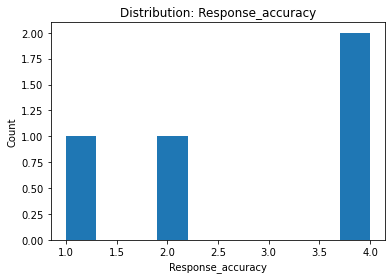

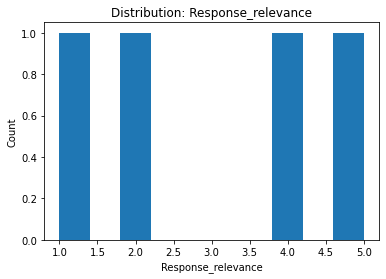

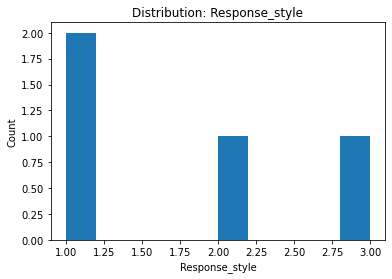

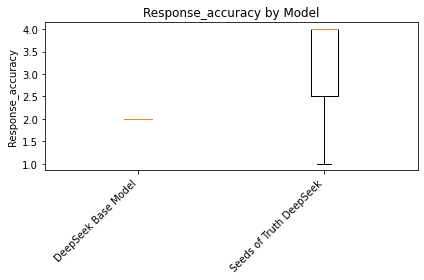

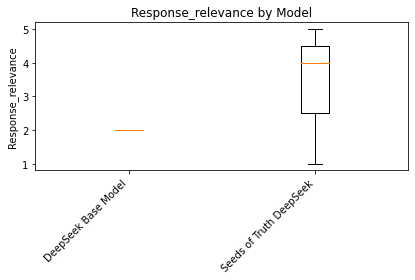

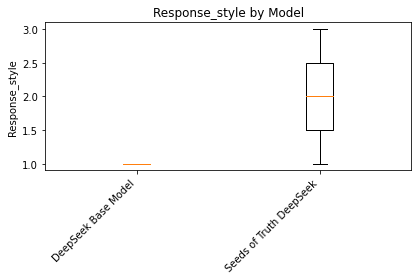

In [1]:
# Evaluate a pipe-delimited testresults.csv and provide a clean HTML view_test()
# - SoT Deepseek 1-40 = original lora, > 40 = Qwen3 with modified handler, 

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import html

# -------------------------------
# Load CSV (no output files)
# -------------------------------
CANDIDATE_PATHS = [
    Path(r"C:/datasources/testresults.csv"),
]
csv_path = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find testresults.csv. Put it at C:/datasources/testresults.csv "
        "or your own path."
    )

df = pd.read_csv(csv_path, sep="|", engine="python")
print(f" Loaded: {csv_path} ({len(df):,} rows)")

# -------------------------------
# Column hygiene
# -------------------------------
def make_unique(names):
    seen = {}
    out = []
    for n in names:
        base = str(n).strip()
        if base in seen:
            seen[base] += 1
            n = f"{base}.{seen[base]}"
        else:
            seen[base] = 0
            n = base
        out.append(n)
    return out

df.columns = make_unique(df.columns)

# -------------------------------
# Identify numeric columns and coerce
# -------------------------------
CORE_NUMERIC = ["Response_accuracy", "Response_relevance", "Response_style"]
ref_numeric = [c for c in df.columns if str(c).lower().endswith("_relevance")]
numeric_cols = list(dict.fromkeys([c for c in CORE_NUMERIC if c in df.columns] + ref_numeric))
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# -------------------------------
# Readable text view (initial dataframe slice)
# -------------------------------
TEXT_COLS_WISHLIST = [
    "Test_number", "Model", "Question_text", "Response_text",
    "General_comment", "Response_comment"
]
text_cols = [c for c in TEXT_COLS_WISHLIST if c in df.columns]
text_view = df[text_cols].copy() if text_cols else pd.DataFrame()
print("\n=== Questions & Comments (readable head) ===")
display(text_view.head(25))

# -------------------------------
# Numeric summaries
# -------------------------------
if numeric_cols:
    print("\n=== Numeric rating summary (describe) ===")
    summary = df[numeric_cols].describe().T
    if "count" in summary.columns:
        summary["count_nonnull"] = summary["count"].astype(int)
    display(summary)

if "Model" in df.columns and numeric_cols and not df.empty:
    print("\n=== Per-model averages (with counts) ===")
    means = df.groupby("Model")[numeric_cols].mean(numeric_only=True)
    counts = df.groupby("Model")[numeric_cols].count()
    per_model = means.join(counts.add_suffix("_count"))
    sort_key = next((c for c in CORE_NUMERIC if c in per_model.columns), numeric_cols[0])
    per_model = per_model.sort_values(by=sort_key, ascending=False)
    display(per_model)

# -------------------------------
# Visualizations (matplotlib only; one chart per fig; no explicit colors)
# -------------------------------
for c in numeric_cols:
    s = df[c].dropna()
    if not s.empty:
        plt.figure()
        s.plot(kind="hist", bins=10, title=f"Distribution: {c}")
        plt.xlabel(c); plt.ylabel("Count")
        plt.show()

if "Model" in df.columns and df["Model"].nunique() > 1:
    for c in [col for col in CORE_NUMERIC if col in df.columns]:
        groups = list(df.groupby("Model"))
        data = [g[c].dropna().values for _, g in groups]
        labels = [name for name, _ in groups]
        if any(len(arr) for arr in data):
            plt.figure()
            plt.boxplot(data, labels=labels)
            plt.title(f"{c} by Model")
            plt.ylabel(c)
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

# -------------------------------
# HTML utilities for view_test()
# -------------------------------
def esc(text):
    """HTML-escape and convert newlines to <br> for nice rendering."""
    if pd.isna(text):
        return "—"
    return html.escape(str(text)).replace("\n", "<br>")

def collect_references_html(row):
    """
    Gather ReferenceN_relevance + ReferenceN_comment into a neat list.
    Shows only those with any content.
    """
    # Find unique "ReferenceX" prefixes
    prefixes = set()
    for c in row.index:
        lc = c.lower()
        if lc.startswith("reference") and ("_relevance" in lc or "_comment" in lc):
            prefixes.add(c.split("_")[0])  # "Reference3"
    # Order numerically if possible
    def key_fn(p):
        try:
            return int(p.replace("Reference", ""))
        except:
            return 10**9
    items = []
    for pref in sorted(prefixes, key=key_fn):
        rel = row.get(f"{pref}_relevance", np.nan)
        com = row.get(f"{pref}_comment", np.nan)
        has_any = (not pd.isna(rel)) or (isinstance(com, str) and com.strip() != "") or (not pd.isna(com))
        if has_any:
            rel_txt = "—" if pd.isna(rel) else esc(rel)
            com_txt = "—" if (pd.isna(com) or str(com).strip() == "") else esc(com)
            items.append(f'''
                <div class="ref-item">
                    <div class="ref-head"><strong>{html.escape(pref)}</strong></div>
                    <div class="ref-body">Relevance: {rel_txt}<br>Comment: {com_txt}</div>
                </div>
            ''')
    if not items:
        return ""
    return '<div class="refs">' + "".join(items) + "</div>"

def row_to_card_html(row):
    """Render a single result as a card with clear sections."""
    test_num = esc(row.get("Test_number", "—"))
    model    = esc(row.get("Model", "—"))

    question = esc(row.get("Question_text", "—"))
    response = esc(row.get("Response_text", "—"))

    gen_comment  = row.get("General_comment", np.nan)
    resp_comment = row.get("Response_comment", np.nan)

    comments_parts = []
    if not (pd.isna(gen_comment) or str(gen_comment).strip() == ""):
        comments_parts.append(f'<div class="comment"><strong>General:</strong> {esc(gen_comment)}</div>')
    if not (pd.isna(resp_comment) or str(resp_comment).strip() == ""):
        comments_parts.append(f'<div class="comment"><strong>Response:</strong> {esc(resp_comment)}</div>')

    refs_html = collect_references_html(row)
    if refs_html:
        comments_parts.append(f'<div class="comment"><strong>References</strong>{refs_html}</div>')

    comments_html = "".join(comments_parts) if comments_parts else '<div class="comment"><em>No comments</em></div>'

    metrics_parts = []
    for m in CORE_NUMERIC:
        if m in row.index and not pd.isna(row[m]):
            metrics_parts.append(f'<span class="metric">{html.escape(m)}: <strong>{esc(row[m])}</strong></span>')
    metrics_html = ("<div class='metrics'>" + " &nbsp; ".join(metrics_parts) + "</div>") if metrics_parts else ""

    return f"""
    <div class="card">
      <div class="card-head">
        <div><strong>Test:</strong> {test_num}</div>
        <div><strong>Model:</strong> {model}</div>
      </div>
      {metrics_html}
      <div class="section">
        <div class="section-title">Question</div>
        <div class="section-body">{question}</div>
      </div>
      <div class="section">
        <div class="section-title">Response</div>
        <div class="section-body">{response}</div>
      </div>
      <div class="section">
        <div class="section-title">Comments</div>
        <div class="section-body">{comments_html}</div>
      </div>
    </div>
    """

CARD_CSS = """
<style>
.viewtest-wrap { font-family: system-ui, -apple-system, Segoe UI, Roboto, Helvetica, Arial, sans-serif; }
.card {
  border: 1px solid #e0e0e0; border-radius: 12px; padding: 16px; margin: 16px 0;
  box-shadow: 0 1px 3px rgba(0,0,0,0.06);
}
.card-head { display: flex; gap: 24px; font-size: 14px; color: #333; margin-bottom: 8px; }
.metrics { margin: 6px 0 12px 0; font-size: 13px; color: #444; }
.metric { display: inline-block; margin-right: 12px; }
.section { margin-top: 10px; }
.section-title { font-weight: 600; font-size: 13px; color: #222; margin-bottom: 6px; text-transform: uppercase; letter-spacing: .02em; }
.section-body { white-space: normal; line-height: 1.45; font-size: 14px; color: #111; }
.section-body .comment { margin: 6px 0; }
.refs { margin-top: 6px; }
.ref-item { margin: 4px 0; padding-left: 8px; border-left: 3px solid #eee; }
.ref-head { margin-bottom: 2px; }
</style>
"""

def view_test(test_number):
    """
    Render all rows matching Test_number as formatted HTML 'cards':
      1) test number & model
      2) well-formatted question
      3) well-formatted response
      4) well-formatted comments (general, response, reference pairs)
    """
    if "Test_number" not in df.columns:
        raise KeyError("No 'Test_number' column found in the CSV.")

    # Match both string and numeric ids robustly
    tn_series = df["Test_number"].astype(str)
    mask = tn_series == str(test_number)
    subset = df.loc[mask]

    if subset.empty:
        display(HTML(CARD_CSS + f"<div class='viewtest-wrap'><em>No rows for Test_number={html.escape(str(test_number))}</em></div>"))
        return subset

    cards = [row_to_card_html(r) for _, r in subset.iterrows()]
    html_block = CARD_CSS + "<div class='viewtest-wrap'>" + "".join(cards) + "</div>"
    display(HTML(html_block))
    return subset  # return the underlying rows in case you want to inspect further

# Example:
# view_test(1)
# view_test("A-12")



In [2]:
view_test(43)

,Test_number,Model,Question_text,Response_text,General_comment,Response_comment,Response_accuracy,Response_relevance,Response_style,Reference1_relevance,...,Reference6_relevance,Reference6_comment,Reference7_relevance,Reference7_comment,Reference8_relevance,Reference8_comment,Reference9_relevance,Reference9_comment,Reference10_relevance,Reference10_comment
3,43,Seeds of Truth DeepSeek,What can you tell me about sex abuse dungeons ...,"n a new book titled 'Sex, Money & Power: How W...",NaN,The base model alone refused to answer this qu...,4.0,4.0,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
